# Credit Default Modelling

This notebook builds and evaluates models for predicting customer default.

In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import log_loss
from sklearn.base import clone

from scipy.optimize import minimize_scalar

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

Separate the predictor variables from the default target and remove client_id.

In [20]:
X = train.drop(columns=["default", "client_id"])
y = train["default"]

X_test = test.drop(columns=["client_id"])

Create lists of columns that are categorical and standardise the remaining numerical features.


In [21]:
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols
        )
    ]
)


Use logistic regression as the first baseline model.


In [23]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=50
)

cv_scores = -cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

baseline_logloss = cv_scores.mean()

print("Fold Log Loss:", cv_scores)
print("Mean CV Log Loss:", baseline_logloss)
print("Standard Deviation:", cv_scores.std())

Fold Log Loss: [0.43757934 0.42918817 0.44323252 0.43680413 0.43591197]
Mean CV Log Loss: 0.43654322437846715
Standard Deviation: 0.004480704353575942


Logistic regression provides a baseline mean CV log loss of 0.4365 for comparison with stronger models.

Use XGBoost as a stronger nonlinear model and evaluate it using the same 5-fold cross-validation setup as the logistic regression baseline.

In [25]:
boost_categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

In [26]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            boost_categorical_cols
        )
    ],
    remainder="passthrough"
)

In [27]:
xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "classifier",
        XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=50,
            n_jobs=-1
        )
    )
])

In [28]:
xgb_scores = -cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

xgb_logloss = xgb_scores.mean()

print("Fold Log Loss:", xgb_scores)
print("Mean CV Log Loss:", xgb_logloss)
print("Standard Deviation:", xgb_scores.std())

Fold Log Loss: [0.42739013 0.41644689 0.43619543 0.43129441 0.42460811]
Mean CV Log Loss: 0.4271869957447052
Standard Deviation: 0.006634221762947777


Use CatBoost as another stronger nonlinear model and evaluate it using the same 5-fold cross-validation setup as the previous models.

In [29]:
cat_scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):

    X_train_fold = X.iloc[train_idx]
    X_valid_fold = X.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        loss_function="Logloss",
        verbose=0,
        random_seed=50,
        thread_count=-1
    )

    cat_model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=boost_categorical_cols
    )

    cat_probs = cat_model.predict_proba(X_valid_fold)[:, 1]

    fold_score = log_loss(
        y_valid_fold,
        cat_probs
    )

    cat_scores.append(fold_score)

    print(f"Fold {fold}: {fold_score:.5f}")

Fold 1: 0.42671
Fold 2: 0.41662
Fold 3: 0.43706
Fold 4: 0.42861
Fold 5: 0.42420


In [30]:
cat_scores = np.array(cat_scores)

cat_logloss = cat_scores.mean()

print("\nFold Log Loss:", cat_scores)
print("Mean CV Log Loss:", cat_logloss)
print("Standard Deviation:", cat_scores.std())


Fold Log Loss: [0.4267056  0.4166158  0.43706394 0.42861445 0.42420285]
Mean CV Log Loss: 0.42664053018775033
Standard Deviation: 0.006617939412801522


Compare results of models so far

In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "CatBoost"
    ],
    "Mean CV Log Loss": [
        baseline_logloss,
        xgb_logloss,
        cat_logloss
    ]
})

results

,Model,Mean CV Log Loss
0,Logistic Regression,0.436543
1,XGBoost,0.427187
2,CatBoost,0.426641


Both boosted models improve on the logistic regression baseline, with CatBoost giving the lowest mean CV log loss.

Add features that summarise repayment behaviour, bill amounts and payment behaviour to see whether they provide additional predictive information.

In [32]:
pay_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

In [33]:
X_fe = X.copy()
X_test_fe = X_test.copy()

X_fe["delayed_months"] = (X_fe[pay_cols] > 0).sum(axis=1)
X_test_fe["delayed_months"] = (X_test_fe[pay_cols] > 0).sum(axis=1)

X_fe["max_delay"] = X_fe[pay_cols].max(axis=1)
X_test_fe["max_delay"] = X_test_fe[pay_cols].max(axis=1)

X_fe["avg_repayment_status"] = X_fe[pay_cols].mean(axis=1)
X_test_fe["avg_repayment_status"] = X_test_fe[pay_cols].mean(axis=1)

X_fe["avg_bill"] = X_fe[bill_cols].mean(axis=1)
X_test_fe["avg_bill"] = X_test_fe[bill_cols].mean(axis=1)

X_fe["avg_payment"] = X_fe[payment_cols].mean(axis=1)
X_test_fe["avg_payment"] = X_test_fe[payment_cols].mean(axis=1)

X_fe["recent_utilisation"] = X_fe["BILL_AMT1"] / X_fe["LIMIT_BAL"]
X_test_fe["recent_utilisation"] = X_test_fe["BILL_AMT1"] / X_test_fe["LIMIT_BAL"]

In [34]:
xgb_fe_scores = -cross_val_score(
    xgb_model,
    X_fe,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

xgb_fe_logloss = xgb_fe_scores.mean()

print("Fold Log Loss:", xgb_fe_scores)
print("Mean CV Log Loss:", xgb_fe_logloss)
print("Standard Deviation:", xgb_fe_scores.std())

Fold Log Loss: [0.42556357 0.41657162 0.4350349  0.4312329  0.42347962]
Mean CV Log Loss: 0.4263765215873718
Standard Deviation: 0.006383432178775376


In [35]:
print("Raw XGBoost:", xgb_logloss)
print("XGBoost + Features:", xgb_fe_logloss)

Raw XGBoost: 0.4271869957447052
XGBoost + Features: 0.4263765215873718


In [36]:
cat_fe_scores = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_fe, y), start=1):

    X_train_fold = X_fe.iloc[train_idx]
    X_valid_fold = X_fe.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    y_valid_fold = y.iloc[valid_idx]

    cat_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        loss_function="Logloss",
        verbose=0,
        random_seed=50,
        thread_count=-1
    )

    cat_model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=boost_categorical_cols
    )

    cat_probs = cat_model.predict_proba(X_valid_fold)[:, 1]

    fold_score = log_loss(y_valid_fold, cat_probs)

    cat_fe_scores.append(fold_score)

    print(f"Fold {fold}: {fold_score:.5f}")

Fold 1: 0.42388
Fold 2: 0.41537
Fold 3: 0.43531
Fold 4: 0.42825
Fold 5: 0.42204


In [37]:
cat_fe_scores = np.array(cat_fe_scores)

cat_fe_logloss = cat_fe_scores.mean()

print("\nFold Log Loss:", cat_fe_scores)
print("Mean CV Log Loss:", cat_fe_logloss)
print("Standard Deviation:", cat_fe_scores.std())


Fold Log Loss: [0.42387969 0.41536903 0.43530678 0.42824819 0.42203554]
Mean CV Log Loss: 0.4249678481708238
Standard Deviation: 0.006626822834946325


Feature engineering improves both boosted models, with CatBoost showing the larger improvement.

Combine the XGBoost and CatBoost probabilities to test whether the two models perform better together (ensemble)

In [38]:
xgb_oof = np.zeros(len(X_fe))
cat_oof = np.zeros(len(X_fe))

In [39]:
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_fe, y), start=1):

    X_train_fold = X_fe.iloc[train_idx]
    X_valid_fold = X_fe.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]

    # XGBoost
    xgb_fold = clone(xgb_model)

    xgb_fold.fit(
        X_train_fold,
        y_train_fold
    )

    xgb_oof[valid_idx] = (
        xgb_fold.predict_proba(X_valid_fold)[:, 1]
    )

    # CatBoost
    cat_fold = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=5,
        loss_function="Logloss",
        verbose=0,
        random_seed=50,
        thread_count=-1
    )

    cat_fold.fit(
        X_train_fold,
        y_train_fold,
        cat_features=boost_categorical_cols
    )

    cat_oof[valid_idx] = (
        cat_fold.predict_proba(X_valid_fold)[:, 1]
    )

    print(f"Finished Fold {fold}")

Finished Fold 1
Finished Fold 2
Finished Fold 3
Finished Fold 4
Finished Fold 5


In [40]:
print("XGBoost OOF:", log_loss(y, xgb_oof))
print("CatBoost OOF:", log_loss(y, cat_oof))

XGBoost OOF: 0.42637652059796993
CatBoost OOF: 0.4249678481708238


In [41]:
blend_oof = (
    0.5 * xgb_oof +
    0.5 * cat_oof
)

blend_logloss = log_loss(
    y,
    blend_oof
)

print("50/50 Blend Log Loss:", blend_logloss)

50/50 Blend Log Loss: 0.4249496225716023


In [42]:
def blend_loss(w):
    blended = (
        w * xgb_oof +
        (1 - w) * cat_oof
    )
    
    return log_loss(y, blended)

result = minimize_scalar(
    blend_loss,
    bounds=(0, 1),
    method="bounded"
)

best_weight = result.x
best_blend_logloss = result.fun

print("Best XGBoost Weight:", best_weight)
print("Best CatBoost Weight:", 1 - best_weight)
print("Best Blend Log Loss:", best_blend_logloss)

Best XGBoost Weight: 0.25644704529717677
Best CatBoost Weight: 0.7435529547028232
Best Blend Log Loss: 0.4247826745877479


The weighted ensemble performs slightly better than either feature-engineered model alone, with most of the weight assigned to CatBoost.

Tune with a small set of model parameters to see whether the XGBoost and CatBoost models can be improved further.

In [43]:
cat_param_sets = [
    {"iterations": 500, "learning_rate": 0.03, "depth": 4},
    {"iterations": 500, "learning_rate": 0.03, "depth": 5},
    {"iterations": 500, "learning_rate": 0.03, "depth": 6},
    {"iterations": 700, "learning_rate": 0.02, "depth": 5},
    {"iterations": 700, "learning_rate": 0.02, "depth": 6},
    {"iterations": 400, "learning_rate": 0.05, "depth": 5},
]

In [44]:
cat_tuning_results = []

for params in cat_param_sets:

    fold_scores = []

    for train_idx, valid_idx in cv.split(X_fe, y):

        X_train_fold = X_fe.iloc[train_idx]
        X_valid_fold = X_fe.iloc[valid_idx]

        y_train_fold = y.iloc[train_idx]
        y_valid_fold = y.iloc[valid_idx]

        model = CatBoostClassifier(
            iterations=params["iterations"],
            learning_rate=params["learning_rate"],
            depth=params["depth"],
            loss_function="Logloss",
            verbose=0,
            random_seed=50,
            thread_count=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            cat_features=boost_categorical_cols
        )

        probs = model.predict_proba(X_valid_fold)[:, 1]

        fold_scores.append(
            log_loss(y_valid_fold, probs)
        )

    cat_tuning_results.append({
        **params,
        "Mean CV Log Loss": np.mean(fold_scores),
        "Standard Deviation": np.std(fold_scores)
    })

In [45]:
cat_tuning_results = pd.DataFrame(
    cat_tuning_results
).sort_values("Mean CV Log Loss")

cat_tuning_results

,iterations,learning_rate,depth,Mean CV Log Loss,Standard Deviation
4,700,0.02,6,0.424350,0.006195
2,500,0.03,6,0.424498,0.006405
3,700,0.02,5,0.424524,0.006292
0,500,0.03,4,0.424872,0.006228
1,500,0.03,5,0.424968,0.006627
5,400,0.05,5,0.425337,0.006270


In [46]:
xgb_param_sets = [
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 3},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 5},
    {"n_estimators": 700, "learning_rate": 0.02, "max_depth": 4},
    {"n_estimators": 700, "learning_rate": 0.02, "max_depth": 5},
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 4},
]

In [47]:
xgb_tuning_results = []

for params in xgb_param_sets:

    tuned_xgb = Pipeline([
        ("preprocessor", xgb_preprocessor),

        ("classifier", XGBClassifier(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=50,
            n_jobs=-1
        ))
    ])

    scores = -cross_val_score(
        tuned_xgb,
        X_fe,
        y,
        cv=cv,
        scoring="neg_log_loss"
    )

    xgb_tuning_results.append({
        **params,
        "Mean CV Log Loss": scores.mean(),
        "Standard Deviation": scores.std()
    })

In [48]:
xgb_tuning_results = (
    pd.DataFrame(xgb_tuning_results)
    .sort_values("Mean CV Log Loss")
)

xgb_tuning_results

,n_estimators,learning_rate,max_depth,Mean CV Log Loss,Standard Deviation
0,500,0.03,3,0.425379,0.006144
3,700,0.02,4,0.425813,0.006173
1,500,0.03,4,0.426377,0.006383
4,700,0.02,5,0.426937,0.006029
2,500,0.03,5,0.427342,0.006357
5,400,0.05,4,0.427693,0.006354


Tuning improves both models, with CatBoost remaining the stronger individual model.

Generate out-of-fold predictions from the tuned models and optimise their ensemble weights.

In [49]:
tuned_xgb_oof = np.zeros(len(X_fe))
tuned_cat_oof = np.zeros(len(X_fe))

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_fe, y), start=1):

    X_train_fold = X_fe.iloc[train_idx]
    X_valid_fold = X_fe.iloc[valid_idx]

    y_train_fold = y.iloc[train_idx]
    
    tuned_xgb = Pipeline([
        ("preprocessor", xgb_preprocessor),

        ("classifier", XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=50,
            n_jobs=-1
        ))
    ])

    tuned_xgb.fit(
        X_train_fold,
        y_train_fold
    )

    tuned_xgb_oof[valid_idx] = (
        tuned_xgb.predict_proba(X_valid_fold)[:, 1]
    )

    tuned_cat = CatBoostClassifier(
        iterations=700,
        learning_rate=0.02,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        random_seed=50,
        thread_count=-1
    )

    tuned_cat.fit(
        X_train_fold,
        y_train_fold,
        cat_features=boost_categorical_cols
    )

    tuned_cat_oof[valid_idx] = (
        tuned_cat.predict_proba(X_valid_fold)[:, 1]
    )

    print(f"Finished Fold {fold}")

Finished Fold 1
Finished Fold 2
Finished Fold 3
Finished Fold 4
Finished Fold 5


In [50]:
print(
    "Tuned XGBoost OOF:",
    log_loss(y, tuned_xgb_oof)
)

print(
    "Tuned CatBoost OOF:",
    log_loss(y, tuned_cat_oof)
)

Tuned XGBoost OOF: 0.42537881200923705
Tuned CatBoost OOF: 0.4243504197171851


In [51]:
def tuned_blend_loss(w):

    blended = (
        w * tuned_xgb_oof +
        (1 - w) * tuned_cat_oof
    )

    return log_loss(y, blended)


result = minimize_scalar(
    tuned_blend_loss,
    bounds=(0, 1),
    method="bounded"
)

tuned_xgb_weight = result.x
tuned_cat_weight = 1 - result.x
tuned_blend_logloss = result.fun

print("XGBoost Weight:", tuned_xgb_weight)
print("CatBoost Weight:", tuned_cat_weight)
print("Tuned Blend Log Loss:", tuned_blend_logloss)

XGBoost Weight: 0.2128142851065431
CatBoost Weight: 0.7871857148934569
Tuned Blend Log Loss: 0.42426614911134675


The tuned ensemble gives the lowest out-of-fold log loss, with approximately 21% weight assigned to XGBoost and 79% to CatBoost.

Fit the tuned models on all labelled data and use the final ensemble to predict default probabilities for the test set.

In [52]:
final_xgb = Pipeline([
    ("preprocessor", xgb_preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=50,
        n_jobs=-1
    ))
])

final_xgb.fit(X_fe, y)

xgb_test_pred = final_xgb.predict_proba(X_test_fe)[:, 1]

In [53]:
final_cat = CatBoostClassifier(
    iterations=700,
    learning_rate=0.02,
    depth=6,
    loss_function="Logloss",
    verbose=0,
    random_seed=50,
    thread_count=-1
)

final_cat.fit(
    X_fe,
    y,
    cat_features=boost_categorical_cols
)

cat_test_pred = final_cat.predict_proba(X_test_fe)[:, 1]

In [54]:
final_pred = (
    0.2128142851 * xgb_test_pred +
    0.7871857149 * cat_test_pred
)

In [55]:
submission = pd.DataFrame({
    "client_id": test["client_id"],
    "default": final_pred
})

submission.to_csv(
    "../submission/submission_tuned_ensemble.csv",
    index=False
)

submission.head()

,client_id,default
0,CC_0012A082B7B7,0.182866
1,CC_0012BC27DFB6,0.157255
2,CC_001563B2143D,0.113074
3,CC_001B46930B6F,0.093141
4,CC_001D771E1C9F,0.053340


Compare all models

In [56]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "CatBoost",
        "XGBoost + Features",
        "CatBoost + Features",
        "Tuned XGBoost",
        "Tuned CatBoost",
        "Tuned Ensemble"
    ],
    "Log Loss": [
        baseline_logloss,
        xgb_logloss,
        cat_logloss,
        xgb_fe_logloss,
        cat_fe_logloss,
        log_loss(y, tuned_xgb_oof),
        log_loss(y, tuned_cat_oof),
        tuned_blend_logloss
    ]
})

display(final_results)

,Model,Log Loss
0,Logistic Regression,0.436543
1,XGBoost,0.427187
2,CatBoost,0.426641
3,XGBoost + Features,0.426377
4,CatBoost + Features,0.424968
5,Tuned XGBoost,0.425379
6,Tuned CatBoost,0.424350
7,Tuned Ensemble,0.424266


Use SHAP on the tuned CatBoost model to identify the main drivers of predicted default risk.
CatBoost is used for interpretation because it is the strongest individual model and contributes around 79% of the final ensemble.

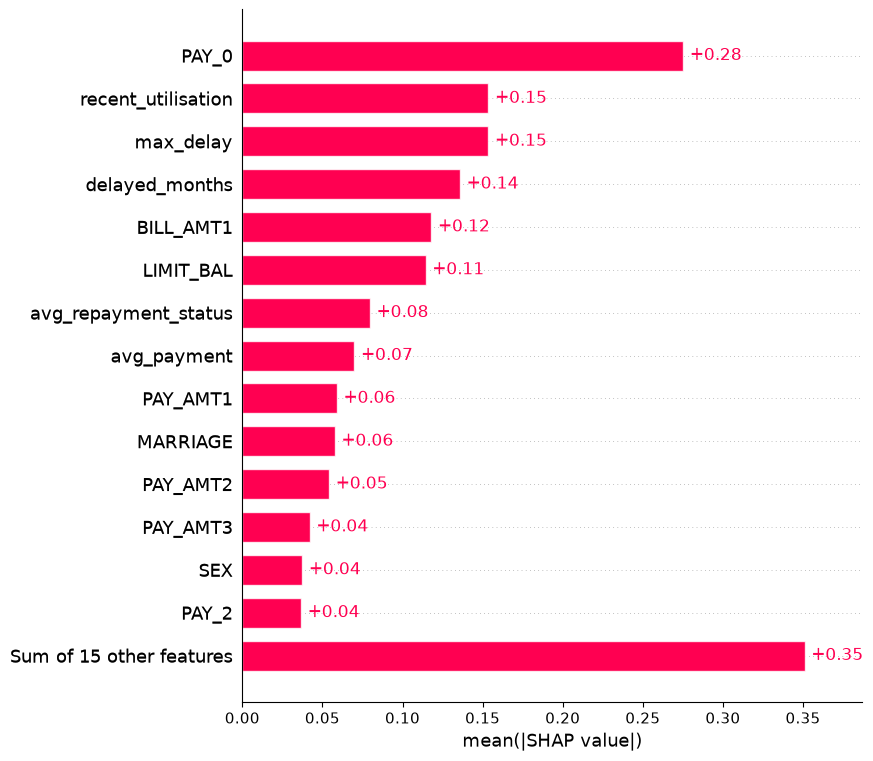

In [57]:
explainer = shap.TreeExplainer(final_cat)
shap_values = explainer(X_fe)

shap.plots.bar(
    shap_values,
    max_display=15
)

Repayment behaviour is the strongest contributor to predicted default risk, with recent repayment status, credit utilisation and repayment delays among the most important features.

Examine whether high and low feature values tend to increase or decrease predicted default risk.

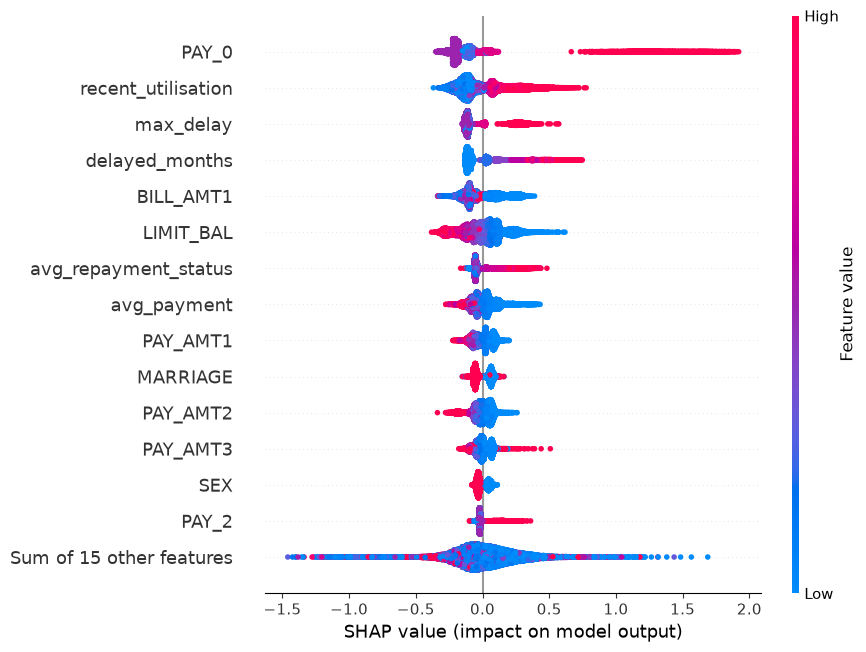

In [58]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

Customers with more severe or repeated repayment delays and higher recent credit utilisation tend to have higher predicted default risk, while larger repayments generally reduce predicted risk.

Group customers by their out-of-fold predicted default risk to see how well the model separates lower and higher risk customers.

In [60]:
business_df = pd.DataFrame({
    "predicted_risk": (
        tuned_xgb_weight * tuned_xgb_oof +
        tuned_cat_weight * tuned_cat_oof
    ),
    "default": y.values
})

In [61]:
business_df["risk_group"] = pd.qcut(
    business_df["predicted_risk"],
    q=5,
    labels=[
        "Lowest",
        "Low",
        "Medium",
        "High",
        "Highest"
    ]
)

Compare the observed default rate across the predicted risk groups.

In [62]:
risk_summary = (
    business_df.groupby(
        "risk_group",
        observed=False
    )
    .agg(
        customers=("default", "count"),
        defaults=("default", "sum"),
        default_rate=("default", "mean")
    )
)

risk_summary["default_rate"] = (
    risk_summary["default_rate"] * 100
).round(2)

risk_summary

,customers,defaults,default_rate
risk_group,,,
Lowest,4800,252,5.25
Low,4800,460,9.58
Medium,4800,754,15.71
High,4800,1072,22.33
Highest,4800,2771,57.73


Visualise how the observed default rate changes across predicted risk grou

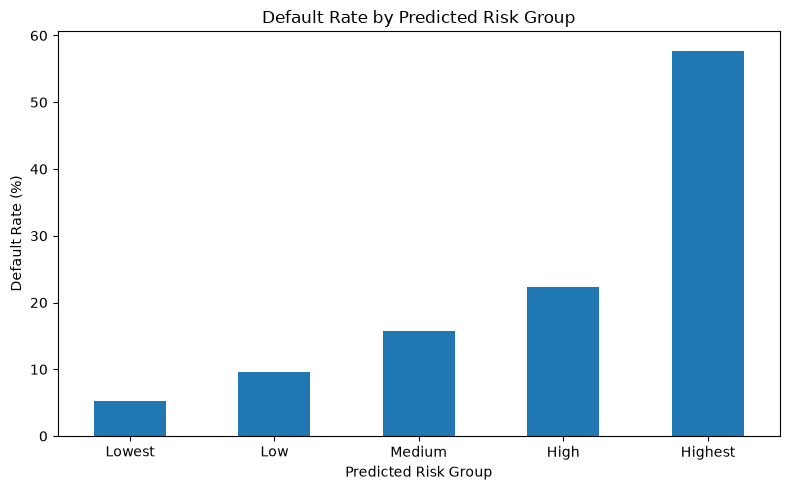

In [71]:
risk_summary["default_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Default Rate by Predicted Risk Group")
plt.xlabel("Predicted Risk Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Default rates increase consistently with predicted risk, rising from 5.25% in the lowest-risk group to 57.73% in the highest-risk group.

Check what proportion of actual defaults are captured by the customers with the highest predicted risk.

In [63]:
business_sorted = business_df.sort_values(
    "predicted_risk",
    ascending=False
)

total_defaults = business_sorted["default"].sum()

for pct in [0.10, 0.20, 0.30]:
    
    n = int(len(business_sorted) * pct)

    captured = (
        business_sorted.iloc[:n]["default"].sum()
        / total_defaults
        * 100
    )

    print(
        f"Top {int(pct*100)}% of customers capture "
        f"{captured:.2f}% of defaults"
    )

Top 10% of customers capture 31.87% of defaults
Top 20% of customers capture 52.19% of defaults
Top 30% of customers capture 63.89% of defaults


The highest-risk 20% of customers contain 52.19% of observed defaults, showing that the model could help target intervention towards a much smaller customer group